# Synapses

NeuRosetta treats synapses as **observations attached to a morphology**, not as
extra graph vertices. Synapses have their own class in NeuRosetta: {class}`~neurosetta.core.synapses.Synapses`.

Synapses can either be their own thing, or mapped directly to a morphology. Mapping here places a synapse as a morphology-relative location on the tree as a continuous pair `(edge_index, edge_fraction)` where `edge_fraction = 0` is the edge source and
`1` is the target.

## Terminology

| Label | Meaning on this neuron |
|-------|-------------------------|
| `pre` / `output` | Presynaptic — output **from** this neuron |
| `post` / `input` | Postsynaptic — input **onto** this neuron |

## Synapses from DataFrames



`partner_id` is the connected neuron ID. Direction depends on type: a `pre`
synapse with partner `B` means this neuron → `B`; a `post` synapse with partner
`B` means `B` → this neuron. `"both"` always means **select pre and post**, never
a third type.

Required columns: `synapse_id`, `type`, `x`, `y`, `z`, `partner_id`. Extra
annotation columns (`confidence`, `cleft_id`, `partner_type`, …) are free-form.



## Functionality

Load an example morphology and build a small synthetic synapse table near real
edge midpoints. In practice: `nr.import_synapses(...)` for an already
per-neuron NeuRosetta-schema table, or `nr.extract_synapses(connectivity_df, neuron_id)`
for a FlyWire / navis-style pre/post connectivity table. Forest batch:
`forest.set_synapses(nr.extract_synapses(df, forest.ids()))`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import neurosetta as nr
from neurosetta import Synapses

%matplotlib inline

tree = nr.load_example_data(nr.example_ids[0])
tree.summary()

ID,nodes,branches,leaves,cable,units,isReduced,Flag
720575940596125868,2010,99,111,404.2,micron,False,False


In [2]:
starts, ends = tree.get_edge_coordinates()
rng = np.random.default_rng(0)
idx = rng.choice(len(starts), size=40, replace=False)
mids = 0.5 * (starts[idx] + ends[idx])
jitter = rng.normal(0, 0.2, size=mids.shape)
types = np.array(["pre"] * 20 + ["post"] * 20)
partners = rng.integers(100, 110, size=40)

df = pd.DataFrame(
    {
        "synapse_id": np.arange(40),
        "type": types,
        "x": mids[:, 0] + np.where(types == "post", jitter[:, 0], 0),
        "y": mids[:, 1] + np.where(types == "post", jitter[:, 1], 0),
        "z": mids[:, 2] + np.where(types == "post", jitter[:, 2], 0),
        "partner_id": partners,
        "partner_type": np.where(partners < 105, "excitatory", "inhibitory"),
        "confidence": rng.uniform(0.5, 1.0, 40),
        "cleft_id": np.arange(40),  # recommended for Forest deduplication
    }
)
df.head()

,synapse_id,type,x,y,z,partner_id,partner_type,confidence,cleft_id
0,0,pre,714.436333,265.090292,231.020417,103,excitatory,0.835031,0
1,1,pre,705.213000,265.270800,202.491300,104,excitatory,0.857309,1
2,2,pre,706.463864,256.017682,206.834727,109,inhibitory,0.583526,2
3,3,pre,704.165467,257.968667,206.834367,106,inhibitory,0.697779,3
4,4,pre,702.318225,269.165925,202.500900,107,inhibitory,0.955128,4


### Bind, map, SoA access

`set_synapses` accepts a DataFrame or a `Synapses` object. `map_synapses()`
projects each observation onto the nearest edge and fills mapping fields.
Core columns live as arrays — use `to_dataframe()` only when you need a pandas
view.

In [3]:
tree.set_synapses(df)
tree.map_synapses()

syn = tree.synapses
syn.summary()

{'n_synapses': 40,
 'n_pre': 20,
 'n_post': 20,
 'n_mapped': 40,
 'n_unmapped': 0,
 'median_distance_to_tree': 0.02000670926229172,
 'max_distance_to_tree': 0.5936545584314784,
 'mapping_valid': True}

In [4]:
print("n pre / post:", len(syn.pre), len(syn.post))
print("aliases:", len(syn.outputs), len(syn.inputs))  # ≡ pre / post
print("types:", syn.types[:5])
print("xyz shape:", syn.coordinates.shape)
print("mapped?", syn.is_mapped, "valid?", syn.mapping_valid)
print("columns:", syn.columns)

# equality / membership filters (type, partner_id, extras, …)
to_100 = syn.filter(partner_id=[100, 101, 102])
print("partners 100–102:", len(to_100))

# boolean masks → take
hi_conf = syn.mask(syn.annotations["confidence"] > 0.8)
print("confidence > 0.8:", len(hi_conf))

tree.count_synapses(type="post"), tree.synapse_density(type="post")


n pre / post: 20 20
aliases: 20 20
types: ['pre' 'pre' 'pre' 'pre' 'pre']
xyz shape: (40, 3)
mapped? True valid? True
columns: ['synapse_id', 'type', 'x', 'y', 'z', 'partner_id', 'partner_type', 'confidence', 'cleft_id', 'edge_index', 'edge_fraction', 'distance_along_edge', 'nearest_x', 'nearest_y', 'nearest_z', 'distance_to_tree', 'mapped']
partners 100–102: 9
confidence > 0.8: 15


(20, 0.049475806901677716)

`filter` supports `type=`, `mapped=`, and `**column_equals` (scalars or
iterables). Add custom columns after the fact with `add_column`:

In [5]:
syn = tree.synapses
print("post only:", len(syn.filter(type="post")))
print("partner 105:", len(syn.filter(partner_id=105)))

syn.add_column("batch", np.full(len(syn), "A"), overwrite=True)
print("batch in columns:", "batch" in syn.columns)

# Standalone construction (owner stamped on bind)
standalone = Synapses(df.head(5), owner_id=tree.ID)
standalone.set_units(tree.get_units())
standalone

post only: 20
partner 105: 6
batch in columns: True


Synapses(n=5, pre=5, post=0, unmapped, owner_id=720575940596125868, units='micron')

### Mapping QC

Raw `(x,y,z)` are immutable observations. Mapping adds `nearest_*`,
`distance_to_tree`, `edge_index` / `edge_fraction`, and `mapped` flags.

In [6]:
path_d = tree.get_synapse_path_distance()
print("path distance shape:", path_d.shape, "finite:", np.isfinite(path_d).all())

tree.synapse_mapping_summary()

path distance shape: (40,) finite: True


{'n_synapses': 40,
 'n_pre': 20,
 'n_post': 20,
 'n_mapped': 40,
 'n_unmapped': 0,
 'median_distance_to_tree': 0.02000670926229172,
 'max_distance_to_tree': 0.5936545584314784,
 'mapping_valid': True}

## 2D plotting

`Tree.show_2d` / `nr.plot_2d` overlay synapses without building a DataFrame.
Use `synapses=` / `show_synapses=` (`True` ≡ `"both"`, or `"pre"` / `"post"`).
`synapse_position` is `"raw"` or `"mapped"`; colour by any column with
`synapse_colour_by`.

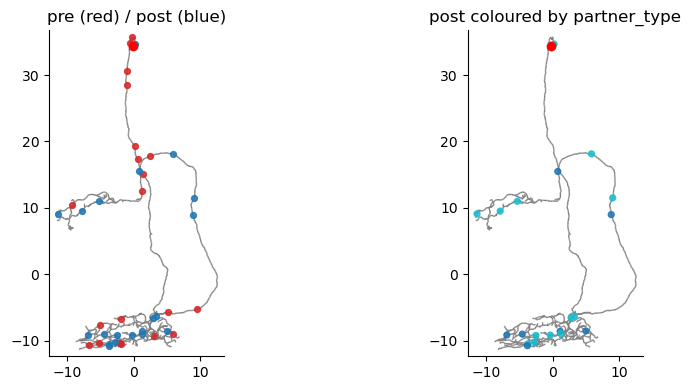

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

tree.show_2d(axes=axes[0], synapses="both", synapse_position="mapped")
axes[0].set_title("pre (red) / post (blue)")

tree.show_2d(
    axes=axes[1],
    synapses="post",
    synapse_position="mapped",
    synapse_colour_by="partner_type",
)
axes[1].set_title("post coloured by partner_type")

fig.tight_layout()

<Axes: >

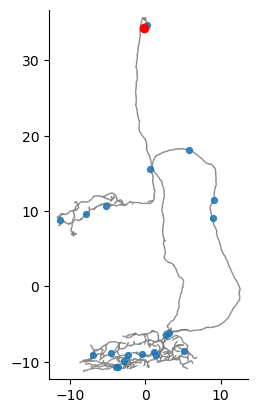

In [8]:
# raw → mapped residual lines
tree.show_2d(
    synapses="post",
    synapse_position="raw",
    show_synapse_mapping=True,
)

## Reduction, connectivity, persistence

### Map before reduce

If synapses are already mapped, reduction **transfers** section identity and
cable position — it does **not** re-run nearest-edge search. Prefer
map-then-reduce so positions stay exact on the original arbor.

In [9]:
t = tree.copy()
before = t.get_synapse_path_distance()
n_edges_before = t.graph.num_edges()
t.get_reduced_tree(inplace=True)
after = t.get_synapse_path_distance()
print("path distance invariant:", np.allclose(before, after))
print("still mapped:", t.synapses.is_mapped)
print("edges:", n_edges_before, "→", t.graph.num_edges())


path distance invariant: False
still mapped: True
edges: 2009 → 210


### Forest connectivity

Direction: `pre` on A with partner B → `A → B`; `post` on A with partner B →
`B → A`. Deduplication (`deduplicate=`): `auto` (default, uses `cleft_id` when
present), `id`, or `none`.

In [10]:
a = nr.load_example_data(nr.example_ids[0]).copy()
b = nr.load_example_data(nr.example_ids[1]).copy()

# tiny reciprocal tables — partner_ids are the other tree's ID
def _edge_mid_synapses(tr, n, type_, partner):
    s, e = tr.get_edge_coordinates()
    m = 0.5 * (s[:n] + e[:n])
    return pd.DataFrame(
        {
            "synapse_id": np.arange(n),
            "type": [type_] * n,
            "x": m[:, 0],
            "y": m[:, 1],
            "z": m[:, 2],
            "partner_id": [partner] * n,
            "cleft_id": np.arange(n),
        }
    )

a.set_synapses(_edge_mid_synapses(a, 5, "pre", b.ID))
b.set_synapses(_edge_mid_synapses(b, 3, "pre", a.ID))
a.map_synapses()
b.map_synapses()

forest = nr.Forest([a, b])
table = forest.get_connectivity_table()
print(table)

g = forest.get_connectivity_graph()
print("directed:", g.is_directed(), "edges:", g.num_edges())
print("out strength:", forest.get_out_strength())

            source_id           target_id  synapse_count
0  720575940596125868  720575940599459782              5
directed: True edges: 1
out strength: {720575940596125868: 5, 720575940599459782: 0}


### Units, I/O, transforms

- Spatial units are collection-level (`syn.units`). On bind / map: both unset →
  warning; mismatch → `ValueError`; success stamps the tree’s units.
  `tree.convert_units(...)` scales morphology **and** synapses.
- Import / export: `nr.import_synapses(...)`, `nr.extract_synapses(...)`
  (FlyWire/navis connectivity tables), `nr.export_synapses(...)`.
  Forest: `forest.set_synapses(extract_synapses(df, forest.ids()))`.
- `.nr` stores synapses as `gp["synapses"]` (pickle payload; trees without
  synapses stay backward-compatible).
- Translate / rotate / uniform scale keep edge assignment and transform raw +
  mapped coords. **Reroot invalidates mapping.** Subtrees:
  `get_subtree(synapses="mapped_only"|"all"|"none")`.

3D overlays: `tree.show_3d(show_synapses=True, synapse_position="raw",
show_synapse_mapping=True)` (vedo / Viewer).

In [11]:
from pathlib import Path
import tempfile

with tempfile.TemporaryDirectory() as tmp:
    path = Path(tmp) / "with_syn.nr"
    nr.save(tree, path)
    loaded = nr.load(path)
    print("round-trip n:", len(loaded.synapses), "mapped:", loaded.synapses.is_mapped)
    print("owner:", loaded.synapses.owner_id == loaded.ID)

round-trip n: 40 mapped: True
owner: True
